In [34]:
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

adata = ad.read_h5ad('../data/pcScores_split_20.h5ad')

/var/folders/5b/9_hm14513rbb1c4_b418y2y00000gn/T/ipykernel_91084/577592078.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')


Text(0.5, 1.0, 'Class Imbalance')

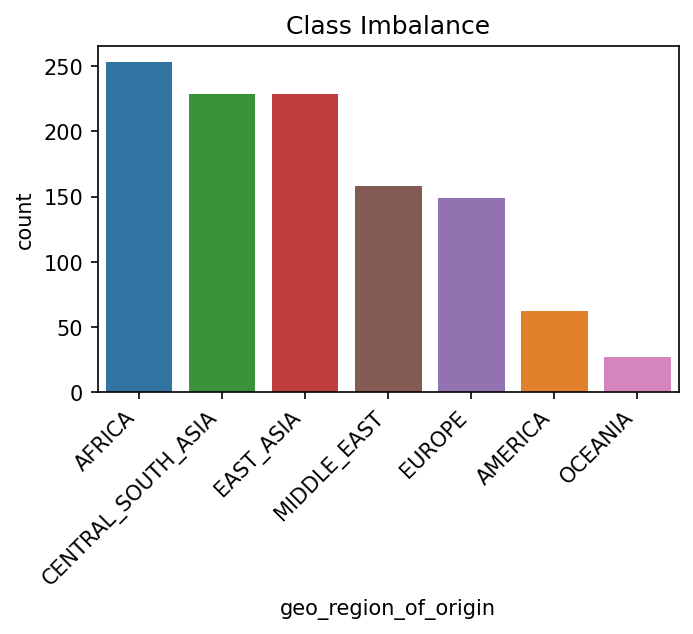

In [46]:
imbal_df = adata.obs['geo_region_of_origin'].value_counts().reset_index(name='count')
region_order = imbal_df.sort_values(by='count',ascending=False)['geo_region_of_origin'].values
fig,ax = plt.subplots(figsize=(5,3),dpi=150)
sns.barplot(data=imbal_df,y='count',x='geo_region_of_origin',order=region_order,ax=ax,hue='geo_region_of_origin')
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')
ax.set_title("Class Imbalance")


In [51]:
adata.obs['geo_region_of_origin'].unique()

['EUROPE', 'MIDDLE_EAST', 'CENTRAL_SOUTH_ASIA', 'OCEANIA', 'AMERICA', 'AFRICA', 'EAST_ASIA']
Categories (7, object): ['AFRICA', 'AMERICA', 'CENTRAL_SOUTH_ASIA', 'EAST_ASIA', 'EUROPE', 'MIDDLE_EAST', 'OCEANIA']

In [59]:
from collections import Counter
def nearest_neighbors_classifier(
    adata,
    y_col='geo_region_of_origin',
    k_neighbors=400,
    label='90/10'
):
    adata = adata.copy()

    # encode classes
    classes = sorted(adata.obs[y_col].unique().tolist())
    class_dict = {c: i for i, c in enumerate(classes)}
    adata.obs['class_id'] = adata.obs[y_col].map(class_dict)


    # remove classes with too few samples
    fold_ids = sorted(list(adata.obsm.keys()))

    class_counts = adata.obs['class_id'].value_counts()
    keep_classes = class_counts[class_counts >= len(fold_ids)].index
    adata = adata[adata.obs['class_id'].isin(keep_classes)].copy()
    
    # get folds
    fold_ids = sorted(list(adata.obsm.keys()))
    adata.obs['fold_' + label] = None

    for i,fold in enumerate(fold_ids):
        # print(fold)
        fold_col = adata.obsm[fold][:,-1]
        test_mask = fold_col == 1
        train_mask = ~test_mask

        X_train = adata.obsm[fold].copy()[train_mask]
        X_test = adata.obsm[fold].copy()[test_mask]
        y_train = adata.obs.loc[train_mask, 'class_id'].to_numpy()

        # squared Euclidean distances
        dists = np.sum((X_test[:, None, :] - X_train[None, :, :]) ** 2, axis=2)

        nn_idx = np.argpartition(dists, k_neighbors - 1, axis=1)[:, :k_neighbors]

        preds = []
        for idx in nn_idx:
            labels = y_train[idx]
            preds.append(Counter(labels).most_common(1)[0][0])

        adata.obs.loc[test_mask, 'pred'] = preds
        adata.obs.loc[test_mask, 'fold_'+label] = i

    return adata
adata = nearest_neighbors_classifier(adata,k_neighbors=21)

In [61]:
adata.obs

,hgdp_id,population_id,population_name,country_of_origin,geo_region_of_origin,genotyping_id,sex,class_id,fold_90/10,pred
0,794,20,Orcadian,OrkneyIslands,EUROPE,938,F,4,1,4.0
1,795,20,Orcadian,OrkneyIslands,EUROPE,939,M,4,0,4.0
2,796,20,Orcadian,OrkneyIslands,EUROPE,940,F,4,2,4.0
3,797,20,Orcadian,OrkneyIslands,EUROPE,941,F,4,1,4.0
4,798,20,Orcadian,OrkneyIslands,EUROPE,942,M,4,1,4.0
...,...,...,...,...,...,...,...,...,...,...
1102,965,699,Yakut,Siberia,EAST_ASIA,741,M,3,1,3.0
1103,966,699,Yakut,Siberia,EAST_ASIA,742,F,3,0,3.0
1104,967,699,Yakut,Siberia,EAST_ASIA,743,F,3,0,3.0
1105,968,699,Yakut,Siberia,EAST_ASIA,744,M,3,0,3.0


In [53]:
from sklearn.metrics import roc_auc_score,f1_score, confusion_matrix
from tqdm.notebook import tqdm
import os

def compute_fpr_fnr(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    fpr = FP / (FP + TN + 1e-12)
    fnr = FN / (FN + TP + 1e-12)

    return fpr, fnr


k_vals = np.concatenate([np.arange(1,30),np.arange(30,101,5)])
n_classes = 7
f1s = np.zeros((4,len(k_vals),10))
fprs = np.zeros((4, len(k_vals), 10, n_classes))
fnrs = np.zeros((4, len(k_vals), 10, n_classes))
split_files = sorted([f for f in os.listdir('../data/') if f.startswith('pcScores')])

for s,split_file in enumerate(split_files):
    adata = ad.read_h5ad(os.path.join('../data',split_file))
    split_no = split_file.split('.')[0][-2:]

    for j,k in tqdm(enumerate(k_vals)):
        adata_result = nearest_neighbors_classifier(adata.copy(),k_neighbors=k,label=split_no)
        region_order = adata_result.obs[['geo_region_of_origin','class_id']].drop_duplicates().sort_values(by='class_id').reset_index(drop=True)['geo_region_of_origin'].tolist()
        fold_col = "fold_"+split_no
        folds = adata_result.obs[fold_col].unique()
        fold_f1s = np.zeros(len(folds))
        for f,fold in enumerate(folds):
            y_true = adata_result[adata_result.obs[fold_col]==fold].obs['class_id'].to_numpy()
            y_pred = adata_result[adata_result.obs[fold_col]==fold].obs['pred'].to_numpy()

            fpr, fnr = compute_fpr_fnr(y_true,y_pred,n_classes)
            f1s[s,j,f] = f1_score(y_true,y_pred,average='macro')
            fprs[s, j, f] = fpr
            fnrs[s, j, f] = fnr


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [54]:
macro_fpr = fprs.mean(axis=3)
macro_fpr

macro_fnr = fnrs.mean(axis=3)
macro_fnr, macro_fpr

(array([[[0.20796066, 0.21001035, 0.23139035, ..., 0.14725155,
          0.20828157, 0.24756494],
         [0.20796066, 0.21001035, 0.23139035, ..., 0.14725155,
          0.20828157, 0.24756494],
         [0.19571946, 0.1945911 , 0.16182513, ..., 0.1195911 ,
          0.15486542, 0.19604978],
         ...,
         [0.25718427, 0.29782091, 0.35819398, ..., 0.31380361,
          0.35859213, 0.35156926],
         [0.286521  , 0.29782091, 0.34867017, ..., 0.31380361,
          0.35859213, 0.36758658],
         [0.286521  , 0.29782091, 0.40581303, ..., 0.33421177,
          0.35859213, 0.36049784]],
 
        [[0.17043502, 0.183481  , 0.23949365, ..., 0.        ,
          0.        , 0.        ],
         [0.17043502, 0.183481  , 0.23949365, ..., 0.        ,
          0.        , 0.        ],
         [0.15780562, 0.15192729, 0.16046484, ..., 0.        ,
          0.        , 0.        ],
         ...,
         [0.28809956, 0.29158142, 0.36115099, ..., 0.        ,
          0.        , 0.

Number of folds: [10, 5, 4, 3]


Text(0.5, 1.0, 'KNN Classification: K vs F1-Score')

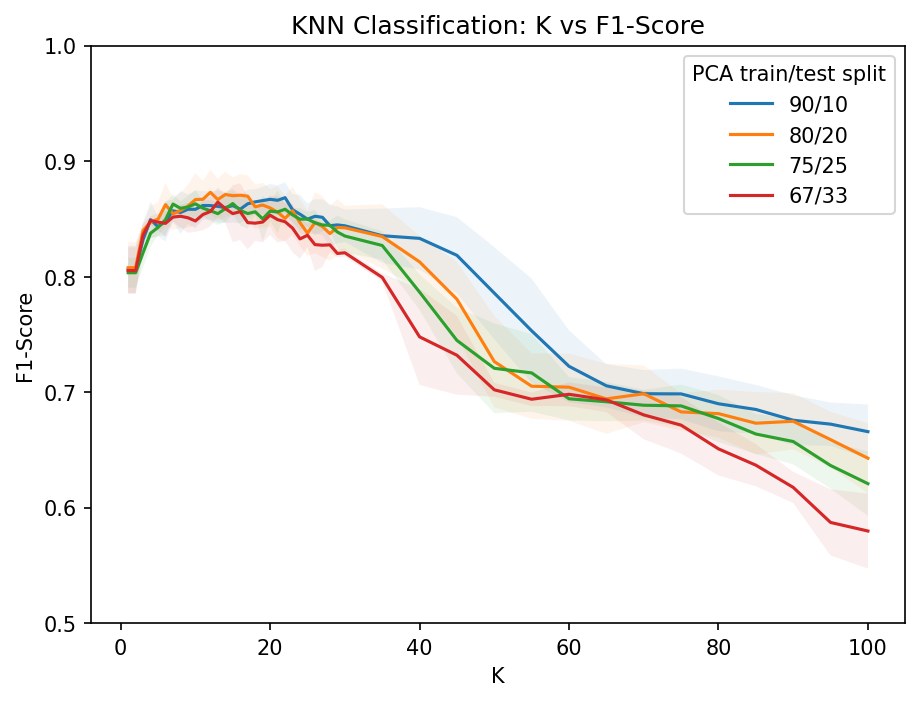

In [68]:
num_folds = [100 // int(split_file.split('.')[0][-2:]) for split_file in split_files]
print(f"Number of folds: {num_folds}")

fig,ax = plt.subplots(figsize=(7,5),dpi=150)

# for i,split in enumerate(split_files):
#     std_err = np.std(f1s[i,:,:num_folds[i]],axis=1) / np.sqrt(num_folds[i])
#     # average f1 across folds
#     split_label = int(split.split('.')[0][-2:])
#     split_label = f"{100-split_label}/{split_label}"
#     f1_means = f1s[i,:,:num_folds[i]].mean(axis=1)
#     # ax.plot(k_vals,f1_means,label=split_label)
#     # ax.scatter(x=k_vals[np.argmax(f1_means)],y=f1_means.max())
#     # ax.annotate(xy=(k_vals[np.argmax(f1_means)],f1_means.max()+0.01),text=f"max: {round(f1_means.max(),4)}"

#     ax.errorbar(k_vals,f1_means,yerr=std_err,label=split_label)


for i,split in enumerate(split_files):
    std_err = np.std(f1s[i,:,:num_folds[i]],axis=1) / np.sqrt(num_folds[i])
    
    split_label = int(split.split('.')[0][-2:])
    split_label = f"{100-split_label}/{split_label}"
    
    f1_means = f1s[i,:,:num_folds[i]].mean(axis=1)

    # line
    ax.plot(k_vals, f1_means, label=split_label)

    # shaded error band
    ax.fill_between(
        k_vals,
        f1_means - 1.96*std_err,
        f1_means + 1.96*std_err,
        alpha=0.08
    )
ax.set_ylabel('F1-Score')
ax.set_xlabel('K')
ax.set_ylim([0.5,1])
ax.legend(title='PCA train/test split')

ax.set_title('KNN Classification: K vs F1-Score')

Number of folds: [10, 5, 4, 3]


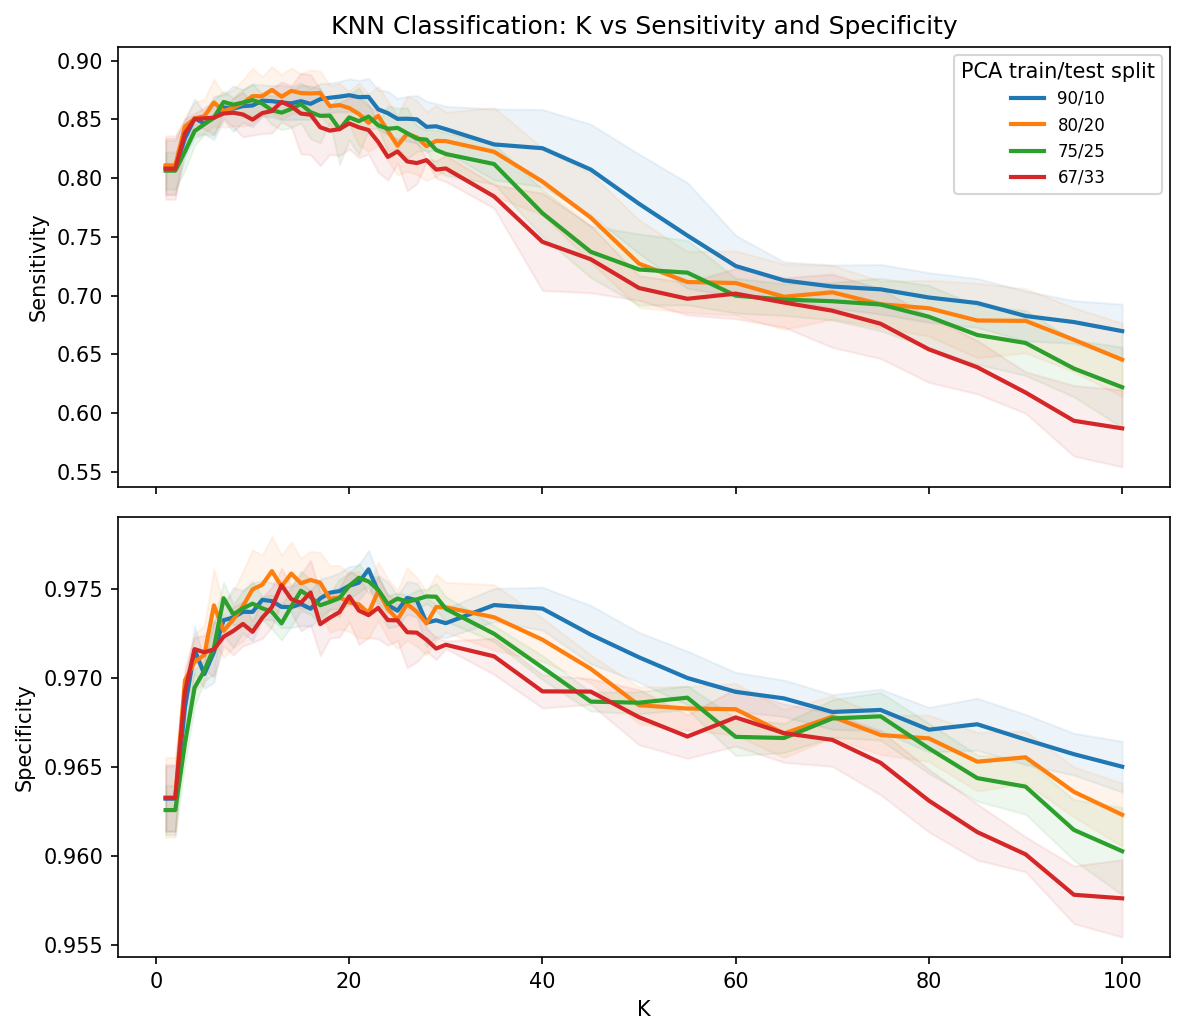

In [69]:
import numpy as np
import matplotlib.pyplot as plt

num_folds = [100 // int(split_file.split('.')[0][-2:]) for split_file in split_files]
print(f"Number of folds: {num_folds}")

fig, (ax_fnr, ax_fpr) = plt.subplots(
    2, 1, figsize=(8, 7), dpi=150, sharex=True
)

for i, split in enumerate(split_files):
    nfold = num_folds[i]

    # shape after slicing: (len(k_vals), nfold, n_classes)
    # average across classes -> (len(k_vals), nfold)
    fpr_macro = fprs[i, :, :nfold, :].mean(axis=2)
    fnr_macro = fnrs[i, :, :nfold, :].mean(axis=2)

    # mean across folds -> (len(k_vals),)
    fpr_means = 1-fpr_macro.mean(axis=1)
    fnr_means = 1-fnr_macro.mean(axis=1)

    # standard error across folds
    fpr_se = fpr_macro.std(axis=1, ddof=1) / np.sqrt(nfold)
    fnr_se = fnr_macro.std(axis=1, ddof=1) / np.sqrt(nfold)

    split_num = int(split.split('.')[0][-2:])
    split_label = f"{100 - split_num}/{split_num}"

    # plot means only
    line_fnr, = ax_fnr.plot(k_vals, fnr_means, linewidth=2, label=split_label)
    color = line_fnr.get_color()

    ax_fpr.plot(k_vals, fpr_means, linewidth=2, color=color, label=split_label)

    # light uncertainty bands instead of error bars
    ax_fnr.fill_between(
        k_vals,
        fnr_means - 1.96*fnr_se,
        fnr_means + 1.96*fnr_se,
        color=color,
        alpha=0.08
    )
    ax_fpr.fill_between(
        k_vals,
        fpr_means - fpr_se,
        fpr_means + fpr_se,
        color=color,
        alpha=0.08
    )

ax_fnr.set_ylabel("Sensitivity")
ax_fpr.set_ylabel("Specificity")
ax_fpr.set_xlabel("K")

ax_fnr.set_title("KNN Classification: K vs Sensitivity and Specificity")

# adjust if needed after seeing your actual ranges
# ax_fnr.set_ylim(0.10, 0.45)
# ax_fpr.set_ylim(0.015, 0.05)

ax_fnr.legend(title="PCA train/test split", fontsize=8)

plt.tight_layout()
plt.show()

,hgdp_id,population_id,population_name,country_of_origin,geo_region_of_origin,genotyping_id,sex
0,794,20,Orcadian,OrkneyIslands,EUROPE,938,F
1,795,20,Orcadian,OrkneyIslands,EUROPE,939,M
2,796,20,Orcadian,OrkneyIslands,EUROPE,940,F
3,797,20,Orcadian,OrkneyIslands,EUROPE,941,F
4,798,20,Orcadian,OrkneyIslands,EUROPE,942,M
...,...,...,...,...,...,...,...
1102,965,699,Yakut,Siberia,EAST_ASIA,741,M
1103,966,699,Yakut,Siberia,EAST_ASIA,742,F
1104,967,699,Yakut,Siberia,EAST_ASIA,743,F
1105,968,699,Yakut,Siberia,EAST_ASIA,744,M


0.8495079770410395
[[0.96047431 0.         0.01976285 0.         0.         0.01976285
  0.        ]
 [0.         0.98387097 0.         0.01612903 0.         0.
  0.        ]
 [0.         0.         0.82532751 0.10480349 0.06113537 0.00873362
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.12751678 0.         0.82550336 0.04697987
  0.        ]
 [0.02531646 0.         0.2278481  0.00632911 0.28481013 0.4556962
  0.        ]
 [0.         0.         0.         0.14814815 0.         0.
  0.85185185]]


Text(0.5, 0.98, 'Normalized Confusion Matrix')

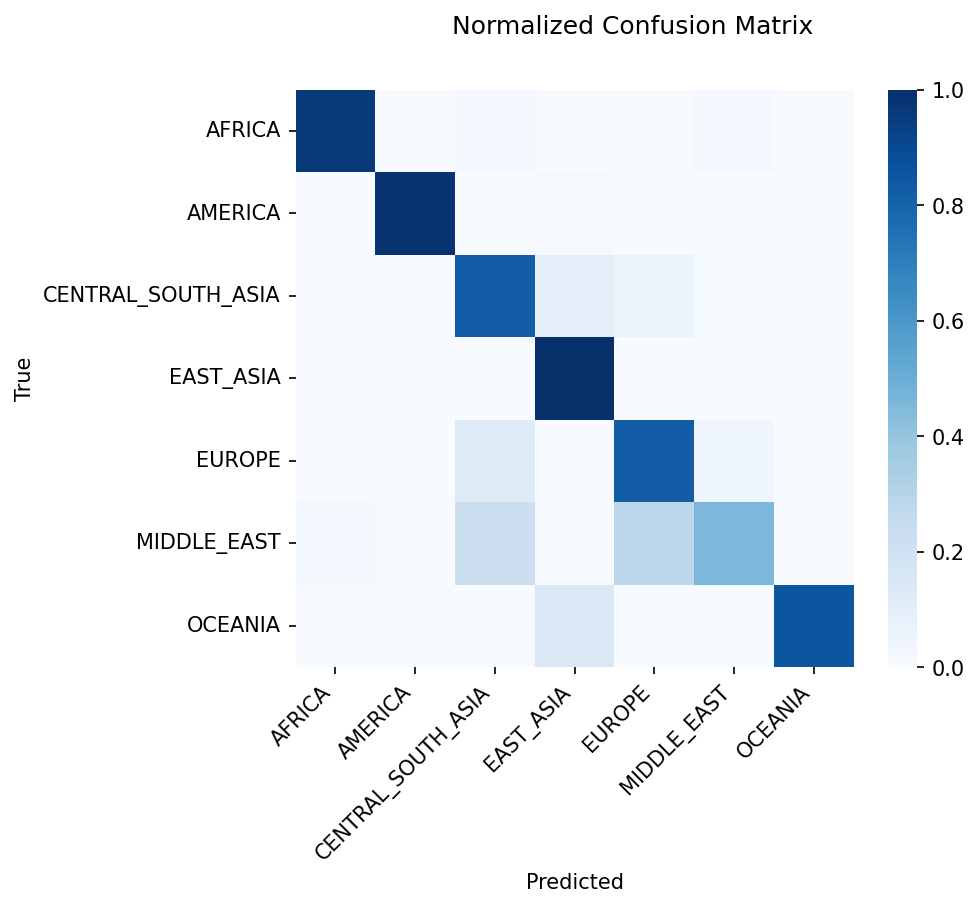

In [64]:


from sklearn.metrics import confusion_matrix
region_order = adata.obs[['geo_region_of_origin','class_id']].drop_duplicates().sort_values(by='class_id').reset_index(drop=True)['geo_region_of_origin'].tolist()
y_true = adata.obs['class_id'].to_numpy()
y_pred = adata.obs['pred'].to_numpy()

print(f1_score(y_true,y_pred,average='macro'))
cm = confusion_matrix(y_true, y_pred)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(6,5),dpi=150)
sns.heatmap(cm_norm, cmap='Blues',ax=ax)
ax.set_xlabel("Predicted")
ax.set_xticklabels(region_order,rotation=45,ha='right')
ax.set_ylabel("True")
ax.set_yticklabels(region_order,ha='right',rotation=0)
# ax.set_xticks(ax.get_xticks()
fig.suptitle("Normalized Confusion Matrix")
